In [2]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix


# FASE 1 - Carregamento e Análise Exploratória de Imagens (EDA)

1 .Importar o dataset MNIST


In [3]:
print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


2. Dimensionalidade das matrizes (X e y) e distribuição das classes 


Shape X: (70000, 784)
Shape y: (70000,)

Tipo de dado das imagens: int64
Valor mínimo de pixel: 0, máximo: 255
Classes únicas: [0 1 2 3 4 5 6 7 8 9]
=== Dimensionalidade das matrizes ===
X: (70000, 784)  -> 70000 amostras, 784 features (pixels)
y: (70000,)

=== Distribuição das classes ===
   Dígito  Quantidade  Percentual
0       0        6903        9.86
1       1        7877       11.25
2       2        6990        9.99
3       3        7141       10.20
4       4        6824        9.75
5       5        6313        9.02
6       6        6876        9.82
7       7        7293       10.42
8       8        6825        9.75
9       9        6958        9.94


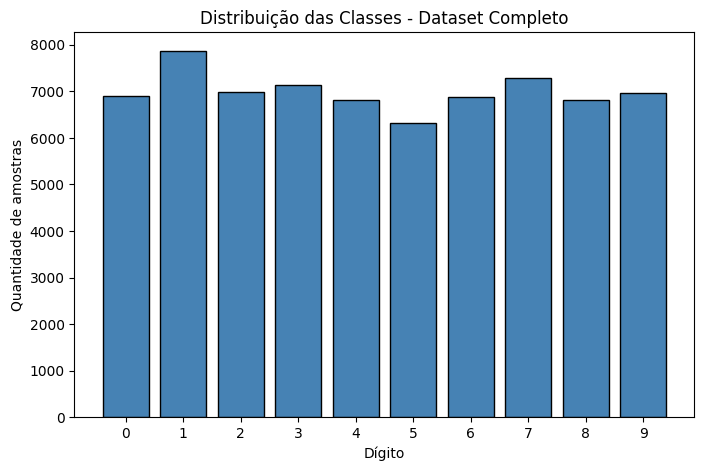

In [9]:
# Separando Entradas (X) e Rótulos (y)
X, y = mnist.data, mnist.target

# o y do fetch_openml vem como string ('0', '1', '2'...)
# por padrão, não como inteiro
y = y.astype(np.uint8)

print(f"Shape X: {X.shape}")   # (70000, 784) -> imagens já "achatadas" em vetores
print(f"Shape y: {y.shape}")   # (70000,)

print(f"\nTipo de dado das imagens: {X.dtype}")
print(f"Valor mínimo de pixel: {X.min()}, máximo: {X.max()}")
print(f"Classes únicas: {np.unique(y)}")

print("=== Dimensionalidade das matrizes ===")
print(f"X: {X.shape}  -> {X.shape[0]} amostras, {X.shape[1]} features (pixels)")
print(f"y: {y.shape}")

print("\n=== Distribuição das classes ===")
valores, contagens = np.unique(y, return_counts=True)
distribuicao = pd.DataFrame({'Dígito': valores, 'Quantidade': contagens})
distribuicao['Percentual'] = (distribuicao['Quantidade'] / distribuicao['Quantidade'].sum() * 100).round(2)
print(distribuicao)

plt.figure(figsize=(8, 5))
plt.bar(valores, contagens, color='steelblue', edgecolor='black')
plt.title('Distribuição das Classes - Dataset Completo')
plt.xlabel('Dígito')
plt.ylabel('Quantidade de amostras')
plt.xticks(valores)
plt.show()
plt.show()



3. Grade visual 2 x 5 com matplotlib

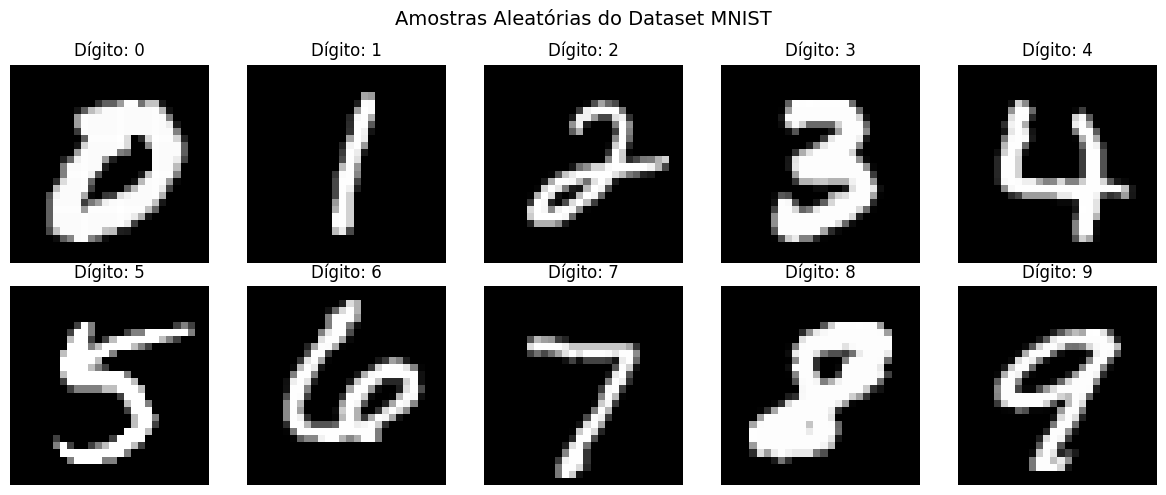

In [10]:
np.random.seed(42)  # para reprodutibilidade (opcional, pode remover)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digito in range(10):
    # Pega todos os índices desse dígito e sorteia um aleatoriamente
    indices_digito = np.where(y == digito)[0]
    idx = np.random.choice(indices_digito)
    
    imagem = X[idx].reshape(28, 28)
    
    linha = digito // 5
    coluna = digito % 5
    
    axes[linha, coluna].imshow(imagem, cmap='gray')
    axes[linha, coluna].set_title(f'Dígito: {digito}')
    axes[linha, coluna].axis('off')

plt.suptitle('Amostras Aleatórias do Dataset MNIST', fontsize=14)
plt.tight_layout()
plt.show()

4. Interpretação a estrutura dos dados: escala de intensidade de pixels (0 a 255), representação vetorial (784 featuras) das imagens bidimensionais (28 x 28)

ESCALA DE INTENSIDADE DE PIXELS: cada pixel da imagem é representado por números inteiros de 0 a 255, onde 0 é o preto absoluto (nenhuma intensidade luminosa) e 255 é o branco absoluto (intensidade máxima), e os valores intermediarios são tons de cinza. 

No caso do MNIST por convenção do dataset o fundo da imagem geralmente é preto (valores próximos de 0) e o traço do dígito escrito aparece em tons claros/brancos (valores próximos de 255) — o oposto de uma folha de papel real.

REPRESENTAÇÃO VETORIAL: Como os modelos clássicos não entendem matrizes 2D de imagem, cada imagem de 28 x 28 é achatada em uma linha com 784 colunas (28 x 28 = 784 variáveis numéricas)

# FASE 2 - Pipeline de Pré-processamento e Divisão dos Dados

1. Divisão estratificada (80% treino e 20% teste)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

print(f"X_train: {X_train.shape} ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"X_test:  {X_test.shape} ({X_test.shape[0]/X.shape[0]*100:.0f}%)")

# Verificando se a estratificação manteve as proporções
import numpy as np
import pandas as pd

prop_treino = pd.Series(y_train).value_counts(normalize=True).sort_index() * 100
prop_teste = pd.Series(y_test).value_counts(normalize=True).sort_index() * 100

comparacao = pd.DataFrame({'Treino (%)': prop_treino.round(2), 'Teste (%)': prop_teste.round(2)})
print("\n=== Comparação de proporções por classe ===")
print(comparacao)

X_train: (56000, 784) (80%)
X_test:  (14000, 784) (20%)

=== Comparação de proporções por classe ===
   Treino (%)  Teste (%)
0        9.86       9.86
1       11.25      11.25
2        9.99       9.99
3       10.20      10.20
4        9.75       9.75
5        9.02       9.02
6        9.82       9.82
7       10.42      10.42
8        9.75       9.75
9        9.94       9.94


2. Normalização / Escalonamento - pixels para a escala [0.0, 1.0]

In [12]:
# --- Normalização dos pixels (0-255 -> 0-1) ---
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("=== Normalização dos pixels ===")
print(f"Antes  -> min: {X_train.min()}, max: {X_train.max()}")
print(f"Depois -> min: {X_train_norm.min()}, max: {X_train_norm.max()}")

=== Normalização dos pixels ===
Antes  -> min: 0, max: 255
Depois -> min: 0.0, max: 1.0


3. Justificativa da importância da normalização

Redes neurais e a maioria dos algoritmos de otimização convergem muito mais rápido e de forma mais estável quando os valores de entrada estão numa escala pequena (0-1), em vez de 0-255

# FASE 3 - Implementação e Treinamento dos 3 modelos

1. Random Forest

2. KNN

3. Rede Neural Perceptron multicamadas 

In [ ]:
modelo_mnist = Sequential([
    # Camada Oculta 1: 128 neurônios para aprender padrões dos 784 pixels
    Dense(128, activation='relu', input_shape=[784]), # note que a camada de entrada é definida quando passamos input_shape=[784]
    
    # Camada Oculta 2: 64 neurônios
    Dense(64, activation='relu'),
    
    # CAMADA DE SAÍDA MULTICLASSE:
    # 10 neurônios (um para cada dígito de 0 a 9) com ativação Softmax
    Dense(10, activation='softmax')
])

modelo_mnist.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    # sparse_categorical_crossentropy é legal quando o nosso target y é número inteiro
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTreinando a Rede Neural no MNIST...")
historico = modelo_mnist.fit(
    X_train_scaled, y_train,
    validation_split=0.1,  # 10% do treino para validação a cada época
    epochs=10,   # 10 passadas completas
    batch_size=64,
    verbose=1 # Mostra uma barra de progresso
)

# O modelo cospe 10 probabilidades por imagem via Softmax
probabilidades = modelo_mnist.predict(X_test_scaled)

# Pegamos o índice da maior probabilidade com np.argmax
y_pred = np.argmax(probabilidades, axis=1)

print("\nPodemos printar o report pra entender como o modelo performou na classificação dos digitos de (0 a 9)")
print(classification_report(y_test, y_pred))

# Visualizando 5 previsões
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].reshape(28, 28), cmap='binary')
    ax.set_title(f"Real: {y_test[i]}\nPred: {y_pred[i]}", 
                 color='green' if y_test[i] == y_pred[i] else 'red')
    ax.axis('off')

plt.suptitle("Exemplos de Predições do Conjunto de Teste", fontsize=14)
plt.tight_layout()
plt.show()




# FASE 4 - Avaliação Comparativa de Desempenho

1. Matriz de confusão com mapa de calor

2. Tabela comparativa (classification_report)
    - Acurácia Global
    - Precisão media ponderada
    - Revocação/ Sensibilidade média ponderada
    - F1 - Score ponderado




# FASE 5 - Desafios

1. Treinamneto restrito com classes ocultadas (class masking)

2. Teste de generalização extrema (inferência OOD)


3. Inferência com imagens manuscritas próprias